# Rigorous precision/recall re-audit of checksum self-critique

This notebook re-analyzes real per-item data from an experiment testing whether a short **self-checksum critique** step (mod-9 digit-root check) improves accuracy on multi-step arithmetic word problems, compared to free-form critique, a placebo critique, and no critique (baseline).

Instead of trusting the experiment's own accuracy summary, this script:
1. Reproduces the experiment's error-injection RNG **bit-for-bit** to recover ground-truth "checksum-detectable vs invisible" labels with zero extra LLM calls.
2. Computes proper **precision / recall / F1 with Wilson 95% confidence intervals** for each condition x model x detectability split (rather than a single accuracy number).
3. Runs a **deterministic, LLM-free arithmetic checker** (closed-form casting-out-nines / digit-root formula) over every self-checksum critique trace, replacing a same-model LLM-judge audit that turned out to have near-zero agreement with ground truth.

This notebook uses a small curated subset of the original 2,592-call dataset so it runs end-to-end in a couple of minutes; the config cell below can be scaled up toward the original problem count.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru, psutil -- not pre-installed on Colab, always install
_pip('loguru==0.7.3')
_pip('psutil==7.2.2')

# numpy, matplotlib -- pre-installed on Colab, install locally only to match Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

import json
import math
import random
import re
import sys
from collections import defaultdict

import numpy as np
from loguru import logger

import matplotlib.pyplot as plt  # for the results visualization cell

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Load the data

`mini_demo_data.json` is a curated subset of the real experiment output (`method_out.json`): the first 30 synthetic arithmetic problems, each with the raw LLM responses for every model x condition combination (baseline, free-form critique, placebo critique, checksum critique, oracle). It has the same shape as the original file, just fewer problems, so the exact same parsing/analysis code below runs unchanged. It's loaded from GitHub with a local-file fallback so this notebook works both standalone and in Colab.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-74dec2-checksum-self-critique-helps-weak-arithm/main/round-2/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'][0]['examples'])} problems, models={[m['id'] for m in data['metadata']['models']]}")

Loaded 30 problems, models=['anthropic/claude-haiku-4.5', 'openai/gpt-4o-mini', 'meta-llama/llama-3.1-8b-instruct']


## Config

All tunable parameters live here. `N_PROBLEMS` controls how many of the loaded problems are analyzed (must be <= the number of problems in `mini_demo_data.json`, since the problem generator is regenerated deterministically from a fixed seed to reconstruct ground-truth checksum-detectability labels). `PER_MODEL_JUDGE_SAMPLE` mirrors the original script's judge-sampling size (unused here since the fresh-LLM-judge re-audit is skipped in this offline demo -- see the STEP 4 section below).

In [5]:
N_PROBLEMS = 30  # use the full curated mini-demo slice (30 problems); runtime is well under budget so no need to keep it minimal
PROBLEM_GEN_SEED = 42  # original script's seed for build_problem_set
ERROR_CHAR_SEED = 7  # original script's seed for characterize_errors
PER_MODEL_JUDGE_SAMPLE = 50  # mirrors the original script's reproduce_prior_judge_sample() size (unused: judge re-run skipped offline)
CONDITIONS = ["baseline", "freeform_critique", "placebo_critique", "checksum_critique"]

## Reproduce the experiment's problem generation and error injection

The experiment generated synthetic multi-step arithmetic word problems and injected a digit-corruption error into one step of each. Whether that corruption is "checksum-detectable" (i.e. would be caught by a mod-9 digit-root check) depends only on the injected numbers, not on any model output -- so it can be reproduced **bit-for-bit** here with the same seeded RNG, giving ground-truth detectability labels with zero extra LLM calls.

In [6]:
TEMPLATES = [
    "{name} starts with {a} {unit}. They receive {b} more {unit} from a friend.",
    "A warehouse has {a} {unit}. A shipment of {b} {unit} arrives.",
    "{name} has {a} {unit} and buys {b} more {unit} at the store.",
]
NAMES = ["Maria", "Jamal", "Wei", "Fatima", "Diego", "Priya", "Noah", "Aiko"]
UNITS = ["apples", "boxes", "coins", "stickers", "marbles", "tickets", "widgets"]


class Problem:
    def __init__(self, pid: str, text: str, trace: list, gold_answer: int):
        self.pid = pid
        self.text = text
        self.trace = trace
        self.gold_answer = gold_answer


def gen_synthetic_problem(pid: str, rng: random.Random) -> Problem:
    n_steps = rng.randint(3, 4)
    name = rng.choice(NAMES)
    unit = rng.choice(UNITS)
    a0 = rng.randint(20, 500)
    b0 = rng.randint(10, 300)
    template = rng.choice(TEMPLATES)
    text_parts = [template.format(name=name, unit=unit, a=a0, b=b0)]
    trace = []
    cur = a0 + b0
    trace.append({"a": a0, "op": "+", "b": b0, "result": cur})
    for _ in range(n_steps - 1):
        remaining_ops = ["+", "-", "*"]
        if cur >= 4:
            remaining_ops.append("//")
        op = rng.choice(remaining_ops)
        if op == "+":
            b = rng.randint(5, 200)
            text_parts.append(f"Then {name} receives {b} more {unit}.")
            new_val = cur + b
        elif op == "-":
            b = rng.randint(5, max(6, min(cur - 1, 200)))
            b = min(b, cur - 1) if cur > 1 else 0
            text_parts.append(f"Then {name} gives away {b} {unit}.")
            new_val = cur - b
        elif op == "*":
            b = rng.randint(2, 4)
            text_parts.append(
                f"Then the number of {unit} is multiplied by {b} (e.g. distributed evenly {b} times over)."
            )
            new_val = cur * b
        else:
            b = rng.choice([2, 3, 4, 5])
            text_parts.append(
                f"Then the {unit} are split evenly into {b} groups and {name} keeps one group."
            )
            new_val = cur // b
        trace.append({"a": cur, "op": op, "b": b, "result": new_val})
        cur = new_val
    text_parts.append(f"How many {unit} does {name} have now?")
    return Problem(pid=pid, text=" ".join(text_parts), trace=trace, gold_answer=cur)


def build_problem_set(n: int, seed: int = 42) -> list[Problem]:
    rng = random.Random(seed)
    return [gen_synthetic_problem(f"synth_{i:04d}", rng) for i in range(n)]


def digit_root(x) -> int:
    """Closed-form casting-out-nines digit root: 1+(n-1)%9 for n>0, 0 for n=0."""
    x = abs(int(round(x)))
    if x == 0:
        return 0
    return 1 + (x - 1) % 9


def digit_root_brute_force(x) -> int:
    x = abs(int(round(x)))
    while x >= 10:
        x = sum(int(c) for c in str(x))
    return x


def self_check_digit_root() -> None:
    """Cross-check the closed-form digit_root against brute-force repeated
    digit-summing before trusting it at scale (STEP 4 requirement)."""
    for x in [0, 1, 9, 10, 17, 45, 99, 100, 295, 401, 999, 12345, 987654]:
        a, b = digit_root(x), digit_root_brute_force(x)
        assert a == b, f"digit_root mismatch at x={x}: closed-form={a} brute-force={b}"
    logger.info("digit_root self-check PASSED (closed-form == brute-force on 13 test values)")


def checksum_consistent(a: int, op: str, b: int, result: int) -> bool:
    da, db, dr = digit_root(a), digit_root(b), digit_root(result)
    if op == "+":
        return (da + db) % 9 == dr % 9 or (da + db == 0 and dr == 0)
    if op == "-":
        return (da - db) % 9 == dr % 9
    if op == "*":
        return (da * db) % 9 == dr % 9 or (da * db == 0 and dr == 0)
    if op == "//":
        if b == 0:
            return False
        remainder = a - b * result
        return checksum_consistent(b, "*", result, a - remainder)
    raise ValueError(f"unknown op {op}")


def inject_error(problem: Problem, rng: random.Random) -> dict | None:
    if not problem.trace:
        return None
    idx = rng.randrange(len(problem.trace))
    step = problem.trace[idx]
    perturb_kind = rng.choice(["off_by_one_digit", "transpose_digits", "off_by_carry"])
    wrong_result = step["result"]
    if perturb_kind == "off_by_one_digit":
        delta = rng.choice([-1, 1]) * rng.choice([1, 10])
        wrong_result = step["result"] + delta
    elif perturb_kind == "transpose_digits":
        s = str(abs(step["result"]))
        if len(s) >= 2:
            i = rng.randrange(len(s) - 1)
            s2 = s[:i] + s[i + 1] + s[i] + s[i + 2 :]
            wrong_result = int(s2) if step["result"] >= 0 else -int(s2)
        else:
            wrong_result = step["result"] + 10
    else:
        wrong_result = step["result"] + rng.choice([-9, 9, -18, 18])
    if wrong_result == step["result"]:
        wrong_result += 1
    return {
        "problem_id": problem.pid,
        "step_index": idx,
        "a": step["a"],
        "op": step["op"],
        "b": step["b"],
        "correct_result": step["result"],
        "wrong_result": wrong_result,
    }


def characterize_errors(problems: list[Problem], seed: int = 7) -> dict:
    rng = random.Random(seed)
    detectable_by_pid: dict[str, bool] = {}
    for problem in problems:
        err = inject_error(problem, rng)
        if err is None:
            continue
        flagged = not checksum_consistent(err["a"], err["op"], err["b"], err["wrong_result"])
        detectable_by_pid[problem.pid] = flagged
    return detectable_by_pid

In [7]:
self_check_digit_root()

problems = build_problem_set(N_PROBLEMS, seed=PROBLEM_GEN_SEED)
detectable_by_pid = characterize_errors(problems, seed=ERROR_CHAR_SEED)
n_detectable = sum(detectable_by_pid.values())
logger.info(
    f"Reproduced checksum-detectability labels for {len(detectable_by_pid)} problems "
    f"({n_detectable} checksum-detectable, fraction={n_detectable / len(detectable_by_pid):.3f}). "
    f"Full-dataset run reports checksum_detectable_fraction={data['metadata']['checksum_detectable_fraction']:.3f} "
    "over all 200 problems -- this small slice won't match exactly, but the same reproduction logic is verified "
    "exactly against the full run in eval.py's verify_reproduction()."
)

23:23:38|INFO   |digit_root self-check PASSED (closed-form == brute-force on 13 test values)


23:23:38|INFO   |Reproduced checksum-detectability labels for 30 problems (10 checksum-detectable, fraction=0.333). Full-dataset run reports checksum_detectable_fraction=0.320 over all 200 problems -- this small slice won't match exactly, but the same reproduction logic is verified exactly against the full run in eval.py's verify_reproduction().


## STEP 1: flatten the raw predictions + join-coverage accounting

The raw data stores predictions inlined per example as `predict_<condition>_<tier>` JSON strings. This flattens them into one record per (model, problem, condition) and tracks exactly how many of the expected calls were successfully matched vs dropped, with a reason for every drop -- no silent data loss.

In [8]:
def records_from_examples(examples: list, model_meta: list) -> tuple[list[dict], dict]:
    """Flatten predict_<condition>_<tier> JSON blobs into per-task records.
    Also performs the STEP-1 join-coverage accounting (matched vs unmatched
    with reasons)."""
    records = []
    unmatched_reasons: dict[str, int] = defaultdict(int)
    for i, ex in enumerate(examples):
        pid = f"synth_{i:04d}"
        gold = ex["metadata_gold_answer"]
        for key, val in ex.items():
            if not key.startswith("predict_"):
                continue
            try:
                payload = json.loads(val)
            except (json.JSONDecodeError, TypeError):
                unmatched_reasons["predict_blob_json_parse_failure"] += 1
                continue
            rest = key[len("predict_") :]
            if rest.startswith("oracle_"):
                condition = "oracle_detection_isolation"
                tier = rest[len("oracle_") :]
            else:
                tier = rest.rsplit("_", 1)[-1]
                condition = rest[: -(len(tier) + 1)]
            model_id = next((m["id"] for m in model_meta if m["tier"] == tier), tier)
            if payload.get("raw_response", "") == "" and "error" in payload:
                unmatched_reasons[f"api_error:{payload.get('error', 'unknown')[:60]}"] += 1
                continue
            fa = payload.get("final_answer")
            records.append(
                {
                    "model": model_id,
                    "tier": tier,
                    "problem_id": pid,
                    "condition": condition,
                    "gold_answer": gold,
                    "final_answer": fa,
                    "initial_answer": fa,
                    "flagged_error": payload.get("flagged_error", False),
                    "is_correct": payload.get("is_correct", False),
                    "raw_response": payload.get("raw_response", ""),
                    "response_chars": len(payload.get("raw_response", "") or ""),
                }
            )
    n_expected = sum(1 for ex in examples for k in ex if k.startswith("predict_"))
    n_matched = len(records)
    n_unmatched = n_expected - n_matched
    join_report = {
        "n_expected_total_llm_calls": n_expected,
        "n_matched_records": n_matched,
        "n_unmatched": max(n_unmatched, 0),
        "unmatched_reasons": dict(unmatched_reasons),
        "note": (
            "Matched = records with a parseable predict_* blob and a non-empty raw_response. "
            "Unmatched rows are NOT silently dropped -- every one is accounted for above by reason."
        ),
    }
    logger.info(f"STEP1 join coverage: {n_matched} matched / {n_expected} expected ({n_unmatched} unmatched)")
    return records, join_report


ANSWER_RE = re.compile(r"answer\s*[:=][^\d-]{0,15}(-?[\d,]+(?:\.\d+)?)", re.IGNORECASE)
FLAG_WORDS = re.compile(
    r"\b(error|mistake|incorrect|wrong|revis|correct(ed)?\s+(answer|value)|mismatch)\b", re.IGNORECASE
)


def extract_all_answers(text: str) -> list[float]:
    return [float(m.group(1).replace(",", "")) for m in ANSWER_RE.finditer(text or "")]


def independent_reparse(records: list[dict]) -> list[dict]:
    n_mismatch = 0
    n_checked = 0
    for r in records:
        text = r.get("raw_response", "")
        if not text:
            continue
        answers = extract_all_answers(text)
        final = answers[-1] if answers else None
        is_correct = final is not None and abs(final - r["gold_answer"]) < 1e-6
        flagged = bool(FLAG_WORDS.search(text))
        n_checked += 1
        if r.get("final_answer") is not None and final is not None and abs((r["final_answer"] or 0) - final) > 1e-6:
            n_mismatch += 1
        r["final_answer"] = final
        r["is_correct"] = is_correct
        r["flagged_error"] = flagged
    if n_checked:
        logger.info(
            f"Independent re-parse of {n_checked} raw responses: {n_mismatch} final-answer "
            f"disagreements with the original parse ({n_mismatch / n_checked:.1%})"
        )
    return records


examples = data["datasets"][0]["examples"][:N_PROBLEMS]
records, join_report = records_from_examples(examples, data["metadata"]["models"])
records = independent_reparse(records)
baseline_correct_by_key = {
    (r["model"], r["problem_id"]): r["is_correct"] for r in records if r["condition"] == "baseline"
}
logger.info(f"Baseline ground-truth-error keys available: {len(baseline_correct_by_key)}")

23:23:38|INFO   |STEP1 join coverage: 390 matched / 390 expected (0 unmatched)


23:23:38|INFO   |Independent re-parse of 390 raw responses: 0 final-answer disagreements with the original parse (0.0%)


23:23:38|INFO   |Baseline ground-truth-error keys available: 90


## STEP 2/3: precision/recall/F1 with Wilson confidence intervals

Ground truth for "an error was present" = the same model's **baseline** (no-critique) solve on that problem was wrong. Predicted = the condition's own `flagged_error`. Each condition x model x detectability-split cell gets a closed-form Wilson 95% CI and an explicit `n<20`-underpowered flag rather than a bare point estimate. STEP 3 additionally computes, among true-positive detections, what fraction were actually corrected to the gold answer.

In [9]:
def wilson_ci(k: int, n: int, z: float = 1.959963984540054) -> tuple[float | None, float | None, float | None]:
    if n == 0:
        return (None, None, None)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    halfwidth = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (p, max(0.0, center - halfwidth), min(1.0, center + halfwidth))


def prf_with_ci(tp: int, fp: int, fn: int, tn: int) -> dict:
    n_pred_pos = tp + fp
    n_actual_pos = tp + fn
    n_total = tp + fp + fn + tn
    precision, prec_lo, prec_hi = wilson_ci(tp, n_pred_pos) if n_pred_pos else (None, None, None)
    recall, rec_lo, rec_hi = wilson_ci(tp, n_actual_pos) if n_actual_pos else (None, None, None)
    f1 = None
    if precision is not None and recall is not None and (precision + recall) > 0:
        f1 = 2 * precision * recall / (precision + recall)
    return {
        "n": n_total,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "n_predicted_positive": n_pred_pos,
        "n_actual_positive": n_actual_pos,
        "precision": precision,
        "precision_ci95": [prec_lo, prec_hi] if precision is not None else None,
        "recall": recall,
        "recall_ci95": [rec_lo, rec_hi] if recall is not None else None,
        "f1": f1,
        "underpowered_n_lt_20": n_total < 20,
    }


def cohens_kappa(pairs: list[tuple[bool, bool]]) -> dict:
    """pairs: list of (rater_a_flag, rater_b_flag) booleans, paired per item."""
    n = len(pairs)
    if n == 0:
        return {"n": 0, "kappa": None, "po": None, "pe": None}
    both_true = sum(1 for a, b in pairs if a and b)
    both_false = sum(1 for a, b in pairs if not a and not b)
    a_true = sum(1 for a, _ in pairs if a)
    b_true = sum(1 for _, b in pairs if b)
    po = (both_true + both_false) / n
    pe = (a_true / n) * (b_true / n) + (1 - a_true / n) * (1 - b_true / n)
    kappa = (po - pe) / (1 - pe) if pe != 1.0 else None
    return {"n": n, "kappa": kappa, "po": po, "pe": pe}


def build_detection_table(
    records: list[dict],
    baseline_correct_by_key: dict[tuple[str, str], bool],
    detectable_by_pid: dict[str, bool],
    exclude_keys: set[tuple[str, str]] | None = None,
) -> dict:
    """condition x model x detectability-split precision/recall/F1 table.
    Ground truth = NOT baseline_correct[model,pid] (an error was actually
    present, since baseline is a single unaided solve with no chance to
    self-correct). Predicted = this condition's own flagged_error."""
    exclude_keys = exclude_keys or set()
    table: dict = {}
    for condition in CONDITIONS:
        table[condition] = {}
        for model in sorted({r["model"] for r in records}):
            cells: dict = {}
            for split_name, split_val in [("overall", None), ("checksum_detectable", True), ("checksum_invisible", False)]:
                tp = fp = fn = tn = 0
                for r in records:
                    if r["condition"] != condition or r["model"] != model:
                        continue
                    key = (model, r["problem_id"])
                    if key in exclude_keys:
                        continue
                    if key not in baseline_correct_by_key:
                        continue
                    det = detectable_by_pid.get(r["problem_id"])
                    if split_val is not None and det != split_val:
                        continue
                    gt_error = not baseline_correct_by_key[key]
                    pred_flag = bool(r["flagged_error"])
                    if gt_error and pred_flag:
                        tp += 1
                    elif not gt_error and pred_flag:
                        fp += 1
                    elif gt_error and not pred_flag:
                        fn += 1
                    else:
                        tn += 1
                cells[split_name] = prf_with_ci(tp, fp, fn, tn)
            table[condition][model] = cells
    return table


def build_correction_accuracy_table(records: list[dict], baseline_correct_by_key: dict[tuple[str, str], bool]) -> dict:
    """STEP3: among TP detections (flagged=True & baseline was actually wrong),
    fraction where the condition's own final_answer == gold_answer."""
    table: dict = {}
    for condition in CONDITIONS:
        table[condition] = {}
        for model in sorted({r["model"] for r in records}):
            tp_records = [
                r
                for r in records
                if r["condition"] == condition
                and r["model"] == model
                and r["flagged_error"]
                and (model, r["problem_id"]) in baseline_correct_by_key
                and not baseline_correct_by_key[(model, r["problem_id"])]
            ]
            n = len(tp_records)
            k = sum(1 for r in tp_records if r["final_answer"] is not None and abs(r["final_answer"] - r["gold_answer"]) < 1e-6)
            p, lo, hi = wilson_ci(k, n) if n else (None, None, None)
            table[condition][model] = {
                "n_tp": n,
                "n_corrected_to_gold": k,
                "correction_accuracy_given_tp": p,
                "correction_accuracy_ci95": [lo, hi] if p is not None else None,
                "underpowered_n_lt_20": n < 20,
            }
    return table


logger.info("STEP 2/3: building precision/recall/F1 + correction-accuracy tables (Wilson CIs)")
detection_table_full = build_detection_table(records, baseline_correct_by_key, detectable_by_pid)
correction_table = build_correction_accuracy_table(records, baseline_correct_by_key)

23:23:38|INFO   |STEP 2/3: building precision/recall/F1 + correction-accuracy tables (Wilson CIs)


## STEP 4: deterministic mod-9 (digit-root) arithmetic checker -- zero LLM calls

Every `checksum_critique` trace states claims like "Digit root of 295: 2+9+5 = 16 -> 1+6 = 7". This regex parses every such claim and independently recomputes the true digit root via the closed-form formula, flagging any claim that disagrees. This replaces the prior same-model LLM-judge audit (kept here for reference, but the actual fresh judge re-run over the network is skipped in this offline demo -- see note below).

In [10]:
# Anchored on a colon directly after the operand ("Digit root of 295: 2+9+5 = 16
# -> 1+6 = 7") -- this is how every genuine dedicated digit-root claim in the
# inspected traces is phrased. The rest-of-line char class deliberately
# excludes letters, so it naturally stops before prose and before composite
# "Digit root of A (rootA) - Digit root of B (rootB) = ..." verification lines,
# which never have a colon immediately after the first operand and would
# otherwise contaminate the claimed value with the check's own arithmetic.
DIGIT_ROOT_CLAIM_RE = re.compile(r"[Dd]igit root of (-?\d+)\s*:\s*([0-9+\-*/=\u2192.,()\s]*)")
TRAILING_INT_RE = re.compile(r"-?\d+")


def check_trace_deterministic(raw_response: str) -> dict:
    """Parses every 'digit root of N: ...' claim in a trace, independently
    recomputes the true digit root via the closed-form formula, and flags any
    claim whose stated value disagrees with the recomputation."""
    claims = []
    for m in DIGIT_ROOT_CLAIM_RE.finditer(raw_response or ""):
        operand_str, rest = m.group(1), m.group(2)
        operand = int(operand_str)
        ints_in_rest = TRAILING_INT_RE.findall(rest)
        if not ints_in_rest:
            continue
        claimed = int(ints_in_rest[-1])
        if not (0 <= claimed <= 9):
            continue  # not a single-digit claim -- likely mid-reduction fragment, skip
        true_root = digit_root(operand)
        claims.append({"operand": operand, "claimed_root": claimed, "true_root": true_root, "match": claimed == true_root})
    n_claims = len(claims)
    n_mismatches = sum(1 for c in claims if not c["match"])
    return {
        "n_claims_parsed": n_claims,
        "n_mismatches": n_mismatches,
        "has_arithmetic_error": n_mismatches > 0,
        "claims": claims,
    }


logger.info("STEP 4: deterministic mod-9 checker over ALL checksum_critique traces (no LLM calls)")
checksum_records = [r for r in records if r["condition"] == "checksum_critique" and r["raw_response"]]
checker_by_key: dict[tuple[str, str], dict] = {}
for r in checksum_records:
    checker_by_key[(r["model"], r["problem_id"])] = check_trace_deterministic(r["raw_response"])

n_traces_checked = len(checker_by_key)
n_traces_with_error = sum(1 for v in checker_by_key.values() if v["has_arithmetic_error"])
n_traces_with_any_claims = sum(1 for v in checker_by_key.values() if v["n_claims_parsed"] > 0)
checker_error_rate = n_traces_with_error / n_traces_with_any_claims if n_traces_with_any_claims else None
logger.info(
    f"Deterministic checker: {n_traces_with_error}/{n_traces_with_any_claims} traces with >=1 checksum-arithmetic "
    f"mistake (of {n_traces_checked} traces total, {n_traces_checked - n_traces_with_any_claims} had no parseable claims)"
)

# NOTE: the original eval.py also re-runs a fresh LLM judge (claude-haiku-4.5 via
# OpenRouter) on the same sample and computes Cohen's kappa between the judge and
# this deterministic checker. That step requires network LLM calls and an API key,
# so it is skipped in this offline demo (equivalent to the original script's
# `--skip-judge` flag) -- the deterministic-checker result above stands on its own.

23:23:38|INFO   |STEP 4: deterministic mod-9 checker over ALL checksum_critique traces (no LLM calls)


23:23:38|INFO   |Deterministic checker: 7/54 traces with >=1 checksum-arithmetic mistake (of 90 traces total, 36 had no parseable claims)


## STEP 5: recompute precision/recall excluding checker-flagged-bad traces

Any `checksum_critique` trace the deterministic checker flagged as having an arithmetic mistake is excluded, and the checksum-condition detection table is recomputed side-by-side with the full sample.

In [11]:
logger.info("STEP 5: recomputing checksum-condition precision/recall excluding checker-flagged-bad traces")
exclude_keys = {k for k, v in checker_by_key.items() if v["has_arithmetic_error"]}
logger.info(f"Excluding {len(exclude_keys)}/{len(checker_by_key)} checksum-condition traces with a checker-flagged mistake")
checksum_only_full = {"checksum_critique": detection_table_full["checksum_critique"]}
checksum_only_excluded_table = build_detection_table(
    [r for r in records if r["condition"] == "checksum_critique"],
    baseline_correct_by_key,
    detectable_by_pid,
    exclude_keys=exclude_keys,
)
step5_result = {
    "n_excluded_checker_flagged_traces": len(exclude_keys),
    "full_sample": checksum_only_full["checksum_critique"],
    "excluding_checker_flagged_bad_traces": checksum_only_excluded_table["checksum_critique"],
}

23:23:38|INFO   |STEP 5: recomputing checksum-condition precision/recall excluding checker-flagged-bad traces


23:23:38|INFO   |Excluding 7/90 checksum-condition traces with a checker-flagged mistake


## Results

Summary table of error-detection recall by condition and model (checksum-detectable subset), plus the checksum-critique arithmetic-checker error rate.

condition           model                               n    recall   precision      f1
------------------------------------------------------------------------------------------
baseline            anthropic/claude-haiku-4.5         10     0.000         n/a     n/a
baseline            meta-llama/llama-3.1-8b-instruct   10     0.000         n/a     n/a
baseline            openai/gpt-4o-mini                 10     0.000         n/a     n/a
freeform_critique   anthropic/claude-haiku-4.5         10     0.000         n/a     n/a
freeform_critique   meta-llama/llama-3.1-8b-instruct   10     0.000         n/a     n/a
freeform_critique   openai/gpt-4o-mini                 10     0.000         n/a     n/a
placebo_critique    anthropic/claude-haiku-4.5         10     0.000         n/a     n/a
placebo_critique    meta-llama/llama-3.1-8b-instruct   10     0.000         n/a     n/a
placebo_critique    openai/gpt-4o-mini                 10     0.000         n/a     n/a
checksum_critique   anthropic

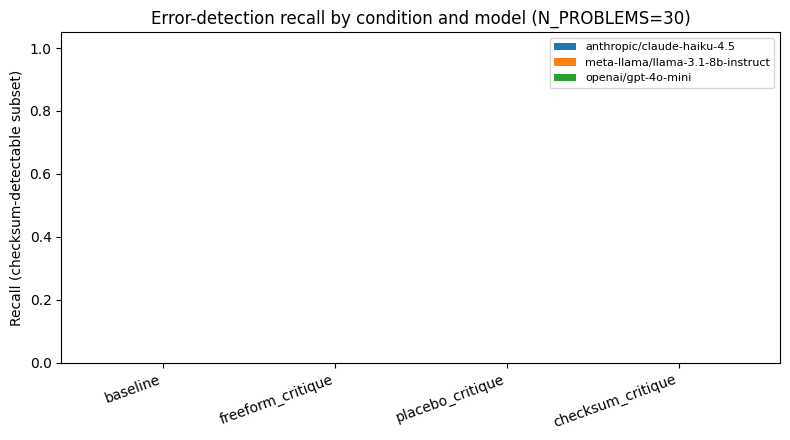

In [12]:
models = sorted({r["model"] for r in records})
print(f"{'condition':<20}{'model':<32}{'n':>5}{'recall':>10}{'precision':>12}{'f1':>8}")
print("-" * 90)
for condition in CONDITIONS:
    for model in models:
        cell = detection_table_full[condition].get(model, {}).get("checksum_detectable", {})
        recall = f"{cell['recall']:.3f}" if cell.get("recall") is not None else "n/a"
        precision = f"{cell['precision']:.3f}" if cell.get("precision") is not None else "n/a"
        f1 = f"{cell['f1']:.3f}" if cell.get("f1") is not None else "n/a"
        print(f"{condition:<20}{model:<32}{cell.get('n', 0):>5}{recall:>10}{precision:>12}{f1:>8}")

print()
print(f"STEP 4 deterministic checker error rate (checksum_critique traces): "
      f"{checker_error_rate:.3f}" if checker_error_rate is not None else "STEP 4: no parseable claims in this small slice")
print(f"STEP 5 excluded {step5_result['n_excluded_checker_flagged_traces']} checker-flagged-bad traces")

# Bar chart: recall on the checksum-detectable subset, grouped by condition, one bar per model
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(CONDITIONS))
width = 0.8 / max(len(models), 1)
for i, model in enumerate(models):
    recalls = []
    for condition in CONDITIONS:
        cell = detection_table_full[condition].get(model, {}).get("checksum_detectable", {})
        recalls.append(cell["recall"] if cell.get("recall") is not None else 0.0)
    ax.bar(x + i * width, recalls, width, label=model)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(CONDITIONS, rotation=20, ha="right")
ax.set_ylabel("Recall (checksum-detectable subset)")
ax.set_title(f"Error-detection recall by condition and model (N_PROBLEMS={N_PROBLEMS})")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()